It analyzes Titanic statistics to identify which features were important for survival during the incident. The homework involves answering 8 questions using our methods and explaining them in a report.

There is 6 features:
- Ticket Class
- Sex
- Age
- Number of siblings and spouses abroad
- Number of parent and child abroad
- The passenger fare

And the label is Survived (1) or not (0)

Traning set : 710 Samples
Test set : 177 Samples

---------------------------------------------

First ı load train and test set

In [ ]:
!wget -q -O titanic-train.txt https://pastebin.com/raw/LDhY3ZTN
!wget -q -O titanic-test.txt https://pastebin.com/raw/zGsE0ZJ6
!ls *.txt

titanic-test.txt  titanic-train.txt


- Read the text
- Parse
- Reshape it
- Slice it
- Arrange types

In [ ]:
import torch
import matplotlib.pyplot as plt

f = open("titanic-train.txt")
data = [float(x) for x in f.read().split()]
f.close()

data = torch.tensor(data).view(-1,7)
X = data[:, :6]
Y = data[:, 6].long()

print(X.shape, X.dtype)
print(Y.shape, Y.dtype)

torch.Size([710, 6]) torch.float32
torch.Size([710]) torch.int64


# **Training the model**

In [ ]:
def logreg_inference(w, b, X):
  logits = X @ w + b
  p = torch.sigmoid(logits)
  return p

**Now its time to write training loop**

In [ ]:
LR = 0.01
STEPS = 20000

w = torch.zeros(6) # Weights for every feature
b = torch.zeros(1)
w.requires_grad_(True)
b.requires_grad_(True)
optimizer = torch.optim.SGD([w,b], lr = LR)

loss_function = torch.nn.BCELoss()

steps = []
losses = []
accuaricies = []

Y_float = Y.float()
for step in range(STEPS):
  optimizer.zero_grad()

  p = logreg_inference(w, b, X)
  loss = loss_function(p, Y_float)

  loss.backward()
  optimizer.step()

  if step % 1000 == 0:
    print(step, loss.item())
    steps.append(step)
    losses.append(loss.item())
    predictions = (p > 0.5).long()
    accuracy = (predictions == Y).float().mean()
    accuaricies.append(accuracy.item())

0 0.6931472420692444
1000 0.9892858266830444
2000 0.606667160987854
3000 0.8056208491325378
4000 0.8128002882003784
5000 0.7487931251525879
6000 0.517934262752533
7000 0.6777580380439758
8000 0.6353226900100708
9000 0.6503862738609314
10000 0.5515993237495422
11000 0.9158216714859009
12000 0.5281330347061157
13000 0.8589257597923279
14000 0.6302241683006287
15000 0.7752619385719299
16000 0.6041083931922913
17000 0.49370211362838745
18000 0.5683485269546509
19000 0.4976786971092224


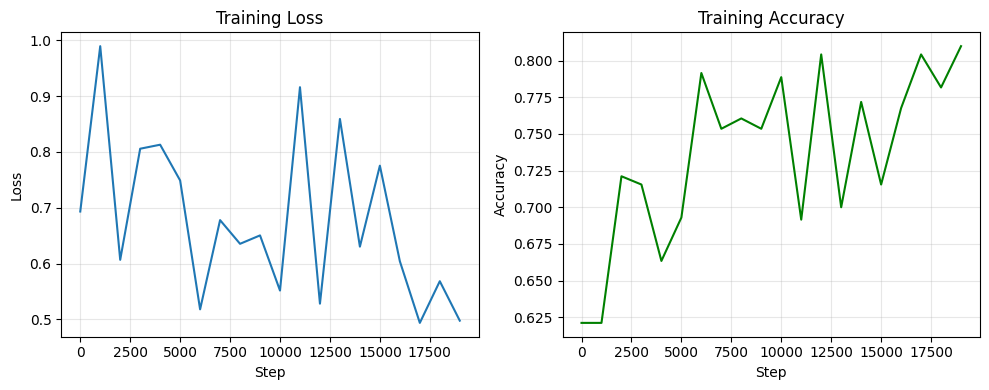

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(steps, losses)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(steps, accuaricies, color='green')
plt.xlabel('Step')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# **Analyze the model**

# **Q1:**
**What would be your probability to survive? (Make a guess about the ticket class, the fare etc.)**

In [ ]:
# My Features -->
Hakan_features = torch.tensor([[1,1,22,2,2,100]])

Hakan_features = Hakan_features.float()

# Probability of survival
p = logreg_inference(w, b, Hakan_features)

print("Passenger's Features: ", Hakan_features)
print(f"Probability of survival: {p.item():.4f}")

Passenger's Features:  tensor([[  1.,   1.,  22.,   2.,   2., 100.]])
Probability of survival: 0.9873


# **Q2:**
**What is the training accuracy of the trained model?**


In [ ]:
p_train = logreg_inference(w, b, X)
predictions = (p_train > 0.5).long()
accuracy = (predictions == Y).float().mean().item()
print(f"Training accuracy: {accuracy:.4f}")

Training accuracy: 0.7789


# **Q3:**
**Looking at the learned weights, how the individual features influence the probability of surviving?**

In [ ]:
print("Learned Weights (w):", w)
print("--------------------------------------------------------------")

print("Learned bias (b):", b)
print("--------------------------------------------------------------")

feature_names = [
    "Ticket Class",
    "Sex",
    "Age",
    "Number of siblings and spouses abroad",
    "Number of parent and child abroad",
    "The passenger fare"
]

for i, weights in enumerate(w):
  print(f"{feature_names[i]}: {weights.item():.4f}")

print(f"Bias : {b.item():.4f}")
print("--------------------------------------------------------------")



Learned Weights (w): tensor([-1.0007,  3.9953, -0.1096, -0.7119, -0.3005,  0.0457],
       requires_grad=True)
--------------------------------------------------------------
Learned bias (b): tensor([1.2169], requires_grad=True)
--------------------------------------------------------------
Ticket Class: -1.0007
Sex: 3.9953
Age: -0.1096
Number of siblings and spouses abroad: -0.7119
Number of parent and child abroad: -0.3005
The passenger fare: 0.0457
Bias : 1.2169
--------------------------------------------------------------


Looking at the learned weights:

- Ticket Class (-0.9975): Negative weight. Since lower class number
  means higher class (1 = upper), a negative weight means that being in
  a lower class (3rd) decreases survival probability. Upper class
  passengers were more likely to survive.

- Sex (3.9953): Strong positive weight. Since Sex = 1 means female,
  this shows that being female strongly increases survival probability.
  This is the most influential feature.

- Age (-0.0644): Slight negative weight. Older passengers had slightly
  lower survival chances, but the effect is small.

- Siblings (-0.7110): Negative weight. Having more siblings or a spouse
  on board decreased survival probability, possibly because it was
  harder to coordinate evacuation with family members.

- Parents (-0.3002): Slight negative weight. Similar effect to SibSp but
  weaker.

- Fare (0.0127): Very small positive weight. Higher fare (richer
  passengers) slightly increased survival, but the effect looks weak
  because Fare values are much larger than other features (0-500), so
  even a small weight has an impact.

The bias (1.2142) is positive, meaning that if all features were zero,
the baseline probability of survival would be above 50%.

# **Q4:**
**What kind of passengers was most likely to survive? And what kind of to**

--------------------------------------
Q3 shows us that the most effective features are Ticket Class (-0.9975)
and Sex (3.9953). These two features affect the survival rate the most.
The other features have a smaller effect (but a lower age also helps
survival). By looking at the signs of these weights (positive or
negative), we can decide what kind of passengers were more likely to
survive or die.

For example:
- Female (1) passengers in 1st class were the most likely to survive.
- Male (0) passengers in 3rd class were the most likely to die.

MOST LIKELY TO SURVIVE: A young female passenger in 1st class with a
high fare and no family on board (~99% survival probability).

MOST LIKELY TO DIE: An older male passenger in 3rd class with a low
fare and a large family on board (~0% survival probability).

In [ ]:

lucky_women = torch.tensor([[1,1,10,0,0,100]]).float()

p = logreg_inference(w, b, lucky_women)

print("Passenger's Features: ", lucky_women)
print(f"Probability of survival: {p.item():.4f}")

print("---------------------------------------------------------")
unlucky_man = torch.tensor([[3,0,70,2,2,10]]).float()

p = logreg_inference(w, b, unlucky_man)

print("Passenger's Features: ", unlucky_man)
print(f"Probability of survival: {p.item():.6f}")

Passenger's Features:  tensor([[  1.,   1.,  10.,   0.,   0., 100.]])
Probability of survival: 0.9995
---------------------------------------------------------
Passenger's Features:  tensor([[ 3.,  0., 70.,  2.,  2., 10.]])
Probability of survival: 0.000016


# **Q5:**
**Draw a scatter plot showing the distribution of the two classes in the plane defined by the two most influential features. Comment the plot**

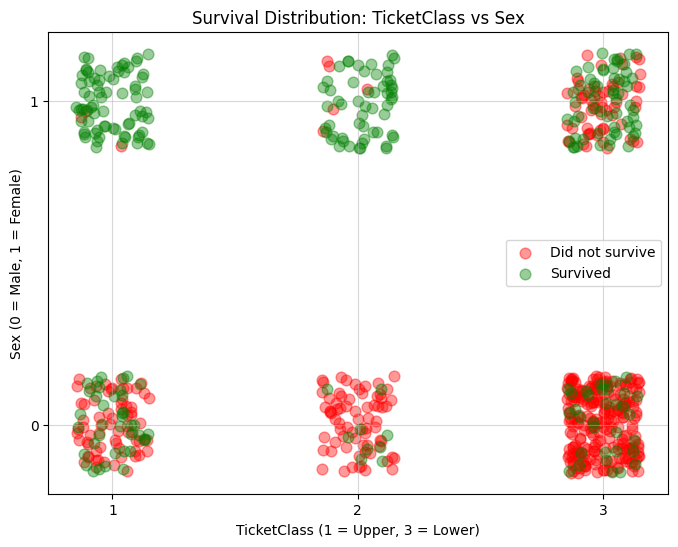

In [ ]:
"""
Ticket Class and Sex is most influential features. Weight index 0 and 1.
"""
import numpy as np

Tclass = X[:, 0].numpy()
sex = X[:, 1].numpy()
y = Y.numpy()

np.random.seed(42)
j = 0.15
Tclass_j = Tclass + np.random.uniform(-j, j, size=Tclass.shape)
sex_j = sex + np.random.uniform(-j, j, size=sex.shape)

plt.figure(figsize=(8, 6))

plt.scatter(Tclass_j[y == 0], sex_j[y == 0],
            c='red', alpha=0.4, label='Did not survive', s=60)

plt.scatter(Tclass_j[y == 1], sex_j[y == 1],
            c='green', alpha=0.4, label='Survived', s=60)

plt.xlabel('TicketClass (1 = Upper, 3 = Lower)')
plt.ylabel('Sex (0 = Male, 1 = Female)')
plt.title('Survival Distribution: TicketClass vs Sex')
plt.xticks([1, 2, 3])
plt.yticks([0, 1])
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

We can obvuislay see that Males in 3rd class is most likely dead on the other hand women in first class is mostly survived
I think it because "Women and children first" policy and first class passengers richer so more important than others

# **Evaluate the script**
Load the test set in the Xtest and Ytest tensors. Then, answer the questions.

In [ ]:
f = open("titanic-test.txt")
data = [float(x) for x in f.read().split()]
f.close()

data = torch.tensor(data).view(-1,7)
X_test = data[:, :6]
Y_test = data[:, 6].long()


print(X_test.shape, X_test.dtype)
print(Y_test.shape, Y_test.dtype)

torch.Size([177, 6]) torch.float32
torch.Size([177]) torch.int64


# **Q6:**
**What is the test accuracy of the model?**

In [ ]:
p_test = logreg_inference(w, b, X_test)

predictions = (p_test > 0.5).long()   # p yerine p_test

test_accuracy = (predictions == Y_test).float().mean().item()

print(f"Test accuracy: {test_accuracy:.4f}")

Test accuracy: 0.8079


#**Q7:**
**Is the model overfitting or underfitting the training?**

----------------------------------------

Difference = train_accuracy - test_accuracy

We can roughly say that:
- Difference > 0.10 → Overfitting
- Difference < 0.05 and both accuracies > 0.75 → Good fit
- Both accuracies low (<0.70) → Underfitting

-------------------------------------
Training accuracy = 0.8113
Test accuracy     = 0.8079
Difference        = 0.0034


Training accuracy = 0.8113 and test accuracy = 0.8079, so the difference is only 0.0034 (~0.3%). In my opinion, the model is neither overfitting nor underfitting — it is a good fit. The training and test accuracies are very close, which shows that the model generalizes well from the training set to unseen data. Both accuracies are around 80%, which I believe is simply the natural limit of this type of model: logistic regression is a linear model and it is working as well as it can on this dataset. A higher accuracy would require a more powerful, non-linear model, but within the boundaries of logistic regression the model is performing well.



# **Q8:**
**How can you increase the performance of the model?**

---------------------------------------


To increase the model's performance, several approaches can be used:

1) Feature scaling / normalization:
   While plotting the loss function, I noticed that the curve was
   bouncing up and down heavily instead of decreasing smoothly. After
   investigating the reason, I found that it was caused by the very
   different scales of the input features, such as Age (0-80) and
   Fare (0-500). When features have such different ranges, gradient
   descent becomes unstable because the gradients for large-scale
   features dominate the updates, causing the loss to oscillate.
   Normalizing each feature to have zero mean and unit variance would
   make gradient descent more stable, speed up convergence, and likely
   result in a smoother and lower final loss.

2) Feature engineering:
   We can add new features based on domain knowledge that are not
   already captured by the existing six features. For example:

   - IsFamous / IsRoyalty: whether the passenger was a celebrity,
     aristocrat, or VIP. Historical records show that famous and royal
     passengers often received priority access to lifeboats, which
     significantly affected their survival chances. This information
     is completely missing from the current features.

   - Age × Pclass (interaction term): Since logistic regression is a
     linear model, it can only look at each feature on its own and
     cannot understand how two features work together. For example, a
     young child in 1st class probably had a much better chance of
     surviving than a young child in 3rd class, but the model cannot
     figure this out by itself. If we multiply Age and Pclass and feed
     it as a new feature, the model can learn this kind of combined
     pattern.

   These features add information that the model could not otherwise
   learn from the raw inputs.

3) Use a more powerful model:
   Even though the model is currently a good fit, a more complex non-linear model like SVM with an RBF kernel could push the accuracy higher by capturing non-linear relationships that logistic regression cannot, as it can capture non-linear relationships that logistic
   regression cannot.

4) More training data:
   In general, increasing the size of the training set is the most
   effective way to improve a model's performance. Unfortunately,
   in this homework it is not possible since the dataset is fixed :)

Among these, the most impactful for this specific case would be
feature scaling (fixing the unstable training) and using a non-linear model (to push beyond the natural limit of logistic regression).